In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("MotorVehicleCollisions.csv")
df.head()

C:\Users\magnu\AppData\Local\Temp\ipykernel_13788\1109691962.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MotorVehicleCollisions.csv")


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,"40,62179","-73,970024","(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [31]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2253192
Number of columns: 29


In [32]:
df.shape
df.dtypes
df.duplicated().sum()
df['COLLISION_ID'].duplicated().sum()

0

In [34]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': df.isna().mean().mul(100).round(2)
}).sort_values('n_missing', ascending=False)

missing.head(20)

,n_missing,pct_missing
VEHICLE TYPE CODE 5,2243302,99.56
CONTRIBUTING FACTOR VEHICLE 5,2242979,99.55
VEHICLE TYPE CODE 4,2217260,98.41
CONTRIBUTING FACTOR VEHICLE 4,2215899,98.34
VEHICLE TYPE CODE 3,2096532,93.05
CONTRIBUTING FACTOR VEHICLE 3,2090099,92.76
OFF STREET NAME,1851532,82.17
CROSS STREET NAME,862706,38.29
ZIP CODE,687745,30.52
BOROUGH,687462,30.51


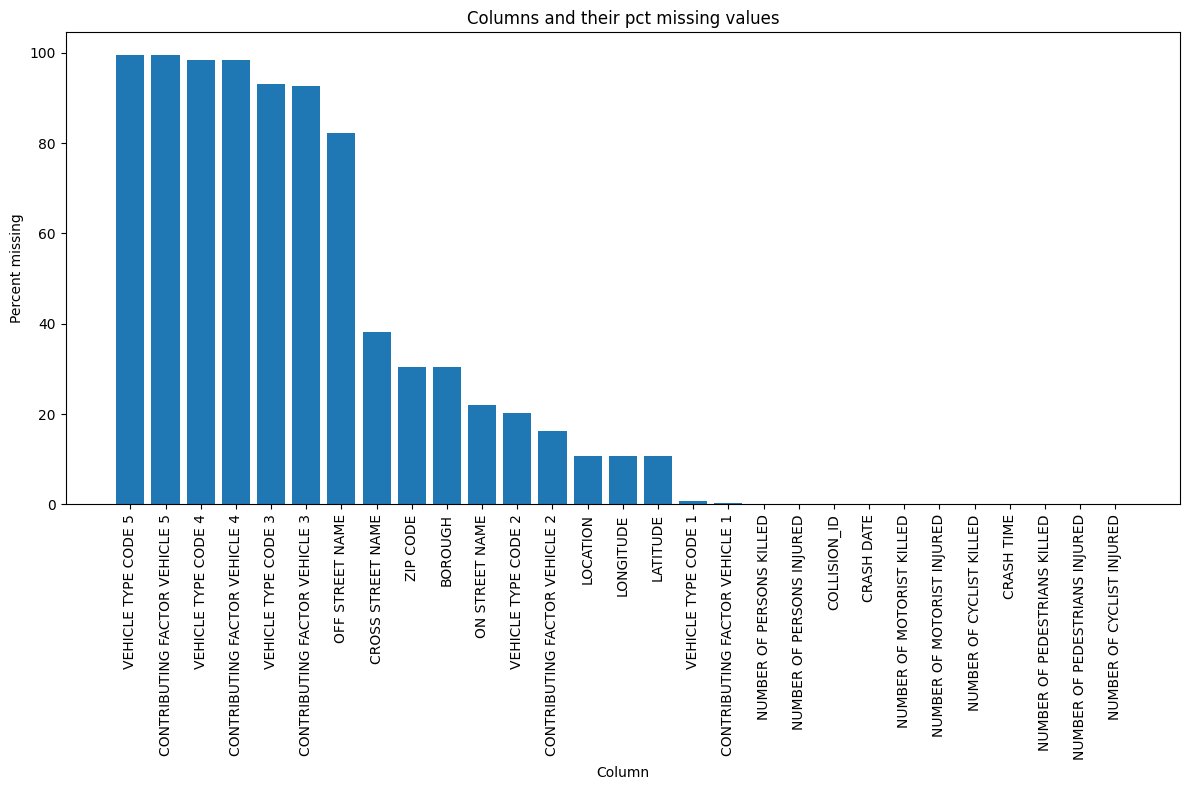

In [35]:
plt.figure(figsize=(12, 8))
plt.bar(missing.index.astype(str), missing["pct_missing"])
plt.xticks(rotation=90)
plt.ylabel("Percent missing")
plt.xlabel("Column")
plt.title("Columns and their pct missing values")
plt.tight_layout()
plt.show()

In [ ]:
# parse date/time
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['CRASH DATETIME'] = (
    df['CRASH DATE'].dt.normalize() +
    pd.to_timedelta(df['CRASH TIME'].dt.hour, unit='h') +
    pd.to_timedelta(df['CRASH TIME'].dt.minute, unit='m')
)
print("Date range:")
print("Start:", df["CRASH DATETIME"].min())
print("End:", df["CRASH DATETIME"].max())

# convert lat/lon if commas are decimal separators
for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace(['nan', 'None'], pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
    

Date range:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00


In [40]:
# Drop rows that dont have spatial or temporal information avaliable.
df_clean =df.dropna(subset=['LATITUDE', 'LONGITUDE','CRASH DATETIME','NUMBER OF PERSONS KILLED','NUMBER OF PERSONS INJURED']).copy()
df_clean.head()
df_clean = df_clean.drop(columns=['CRASH DATE', 'CRASH TIME','LOCATION','VEHICLE TYPE CODE 5','CONTRIBUTING FACTOR VEHICLE 5',
                 'VEHICLE TYPE CODE 4','VEHICLE TYPE CODE 3','CONTRIBUTING FACTOR VEHICLE 4','CONTRIBUTING FACTOR VEHICLE 3',
                 "OFF STREET NAME"])

Notes on data preprocessing:

* Rows represent collision events or incidents. 
* No duplicate rows were found "COLLISION_ID" is unique
* Many missing values are found specifically in columns such as VEHICLE TYPE CODE (X>=3) CONTRIBUTING FACTOR VEHICLE (X>=3) which is most likely due to many collisions not including over 2 contributing factors or vehicles. These are all removed. Further "OFF STREET NAME" is removed since it had high pct missing values. 
* (Maybe all location identifies except LAT/LON?)
* A new column that represent both date and time in datetime format is created. The old two columns are removed
* Latitude and Longitude columns are normalized to be seperated by "."
* Data is cleaned by removing all rows that do not have any spatial or tempral information. It was however seen that no date or time values were missing.
* Also rows where number of person injured/killed are removed since we want to investigate these things.

In [38]:
print("Number of rows in cleaned data:", df_clean.shape[0])
print("Number of rows dropped:", df.shape[0]-df_clean.shape[0])
print("Number of columns in cleaned data:", df_clean.shape[1])
print("Number of columns dropped:", df.shape[1]-df_clean.shape[1])
print("Date range in cleaned data:")
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Number of rows in cleaned data: 2012482
Number of rows dropped: 240710
Number of columns in cleaned data: 20
Number of columns dropped: 10
Date range in cleaned data:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00


To make the data complete, years that are incomplete with data will be dropped. The data start in the middle of 2012 and ends during 2026 hence we will drop these two years:

In [41]:
df_clean = df_clean[~df_clean["CRASH DATETIME"].dt.year.isin([2012, 2026])].copy()
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Start: 2013-01-01 00:01:00
End: 2025-12-31 23:58:00


# When, Where and who are the NYC streets most dangerous for in terms of crashes?

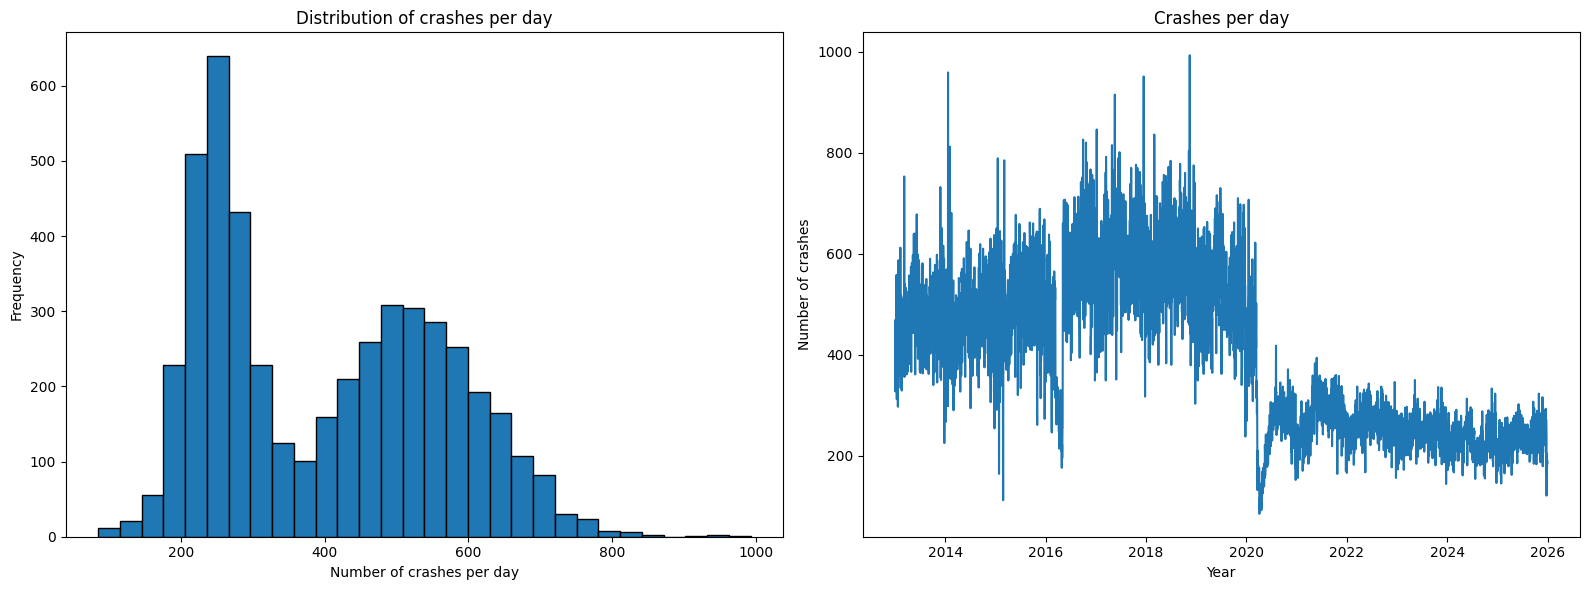

In [59]:
crashes_per_day = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.date)
      .size()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(crashes_per_day, bins=30,edgecolor="black")
axes[0].set_xlabel("Number of crashes per day")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of crashes per day")

axes[1].plot(crashes_per_day.index, crashes_per_day.values)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of crashes")
axes[1].set_title("Crashes per day")

plt.tight_layout()
plt.show()

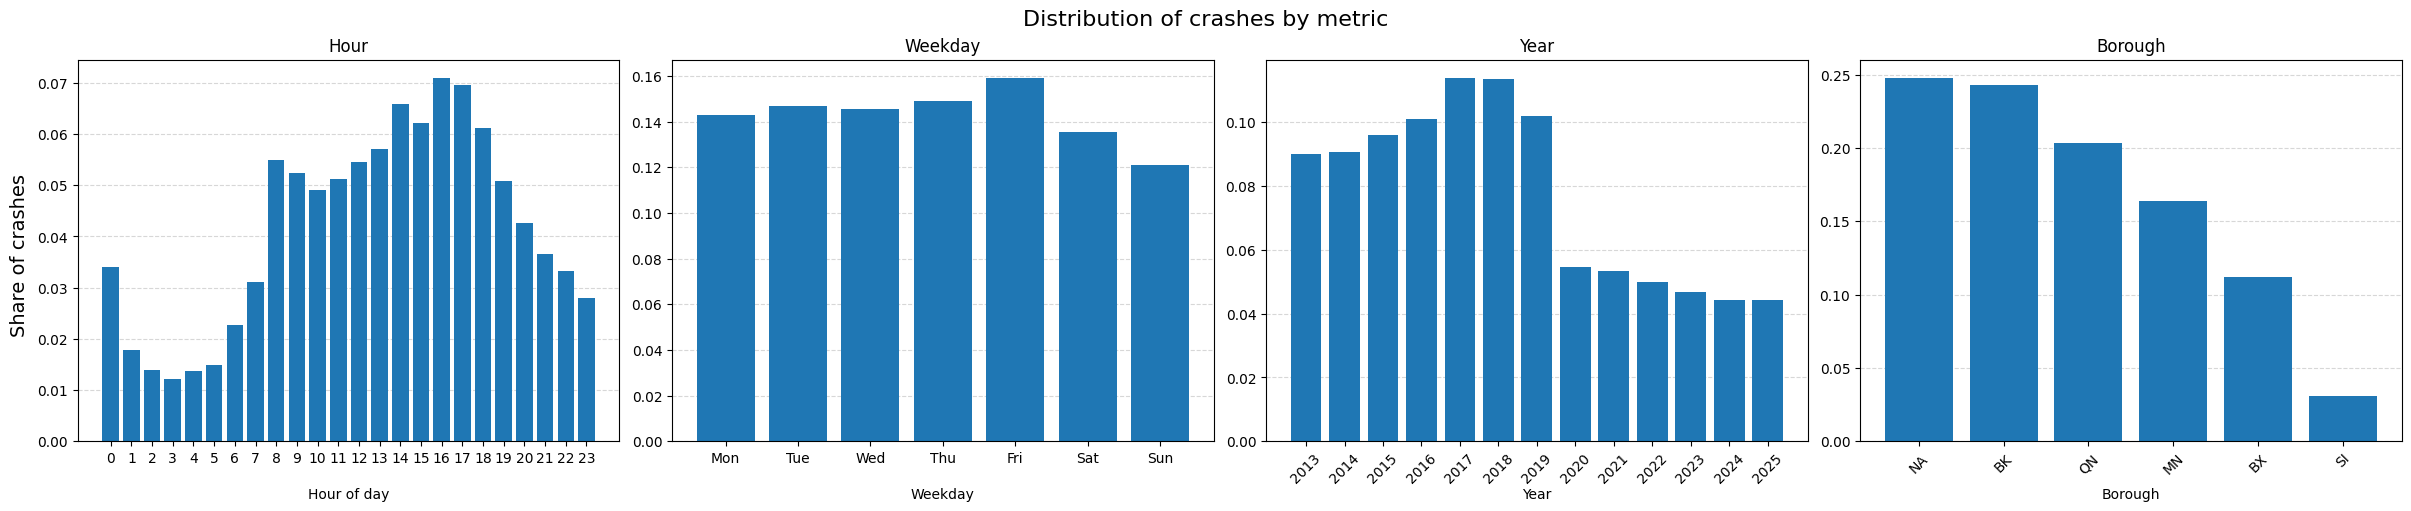

In [ ]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
crashes_by_weekday = (
    df_clean.assign(weekday=df_clean["CRASH DATETIME"].dt.strftime("%a"))
    .groupby("weekday")
    .size()
    .reindex(weekday_order, fill_value=0)
)


crashes_by_hour = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.hour)
    .size()
    .reindex(range(24), fill_value=0)
)


crashes_by_year = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.year)
    .size()
    .sort_index()
)


borough_map = {
    "BRONX": "BX",
    "BROOKLYN": "BK",
    "MANHATTAN": "MN",
    "QUEENS": "QN",
    "STATEN ISLAND": "SI",
    "Unknown": "NA"
}

crashes_by_borough = (
    df_clean["BOROUGH"]
      .fillna("Unknown")
      .replace(borough_map)
      .value_counts()
      .reindex(["BX", "BK", "MN", "QN", "SI", "NA"], fill_value=0)
)

crashes_by_hour_share = crashes_by_hour / crashes_by_hour.sum()
crashes_by_weekday_share = crashes_by_weekday / crashes_by_weekday.sum()
crashes_by_year_share = crashes_by_year / crashes_by_year.sum()
crashes_by_borough = crashes_by_borough.sort_values(ascending=False)
crashes_by_borough_share = crashes_by_borough / crashes_by_borough.sum()

fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)

axes[0].bar(crashes_by_hour.index, crashes_by_hour_share.values)
axes[0].set_title("Hour")
axes[0].set_xlabel("Hour of day")
axes[0].set_xticks(range(24))

axes[1].bar(crashes_by_weekday.index, crashes_by_weekday_share.values)
axes[1].set_title("Weekday")
axes[1].set_xlabel("Weekday")

axes[2].bar(crashes_by_year.index.astype(str), crashes_by_year_share.values)
axes[2].set_title("Year")
axes[2].set_xlabel("Year")
axes[2].tick_params(axis="x", rotation=45)

axes[3].bar(crashes_by_borough.index.astype(str), crashes_by_borough_share.values)
axes[3].set_title("Borough")
axes[3].set_xlabel("Borough")
axes[3].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.xaxis.set_label_coords(0.5, -0.12)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Distribution of crashes by metric", fontsize=16)
fig.supylabel("Share of crashes", fontsize=14)

plt.show()